# 🏏 IPL Fan Segmentation & Revenue Optimization — K-Means Clustering

**Session 3 | Case Study 2 | DSA & ML for Business**

---

### Business Context
- IPL 2023 viewership: **505 million** across TV + streaming
- Media rights deal: **₹48,390 Crore ($5.9B)** for 2023-2027
- Revenue streams: tickets, merchandise, sponsorship, streaming, fantasy gaming
- **Not all fans are equal** — need to identify premium segments for revenue optimization

### What You'll Learn
1. **K-Means clustering** to segment fans by behavior
2. **Profile fan personas** — Stadium Superfan, Digital-Only, Casual Viewer, etc.
3. **Revenue per fan analysis** by segment
4. **Targeted campaign design** for each segment
5. **ROI estimation** for conversion campaigns

## Step 1: Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("../datasets/ipl_fan_segmentation.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.describe().round(2)

Dataset shape: (2500, 7)
Columns: ['fan_id', 'match_attendance', 'merchandise_spend', 'social_engagement_score', 'streaming_hours', 'fantasy_spend', 'loyalty_index']


,match_attendance,merchandise_spend,social_engagement_score,streaming_hours,fantasy_spend,loyalty_index
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,3.47,8216.95,0.57,45.44,7926.55,0.58
std,3.91,10527.07,0.24,25.69,11794.47,0.27
min,0.00,1.78,0.05,5.01,0.21,0.10
25%,1.00,785.98,0.42,25.55,605.71,0.34
50%,2.00,1849.24,0.61,42.00,2584.70,0.54
75%,5.00,14947.56,0.75,58.72,9745.19,0.84
max,14.00,39948.99,1.00,119.90,49984.46,1.00


## Step 2: Feature Scaling & Optimal K Selection

K=3 | Inertia:    5,304.7 | Silhouette: 0.4993
K=4 | Inertia:    3,958.6 | Silhouette: 0.4980
K=5 | Inertia:    2,942.2 | Silhouette: 0.4686
K=6 | Inertia:    2,491.8 | Silhouette: 0.4329
K=7 | Inertia:    2,202.7 | Silhouette: 0.4094
K=8 | Inertia:    2,049.0 | Silhouette: 0.3897


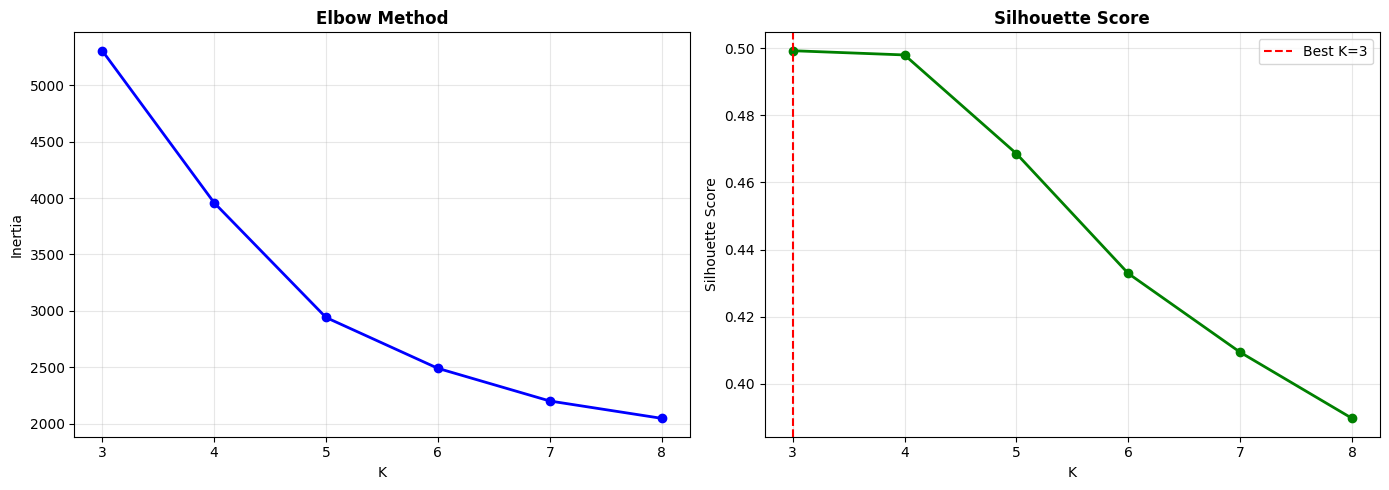

In [2]:
# Scale features
feature_cols = ['match_attendance', 'merchandise_spend', 'social_engagement_score',
                'streaming_hours', 'fantasy_spend', 'loyalty_index']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

# Elbow & Silhouette
K_range = range(3, 9)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"K={k} | Inertia: {km.inertia_:>10,.1f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold'); axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold'); axes[1].grid(True, alpha=0.3)

optimal_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'Best K={optimal_k}')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 3: Clustering & Segment Profiling

In [3]:
# Run K-Means with K=5
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Profile clusters
profile = df.groupby('cluster')[feature_cols].mean().round(2)

# Name segments based on dominant behavior
def name_segment(row):
    if row['match_attendance'] > 5 and row['merchandise_spend'] > 5000:
        return '🏟️ Stadium Superfan'
    elif row['match_attendance'] <= 1 and row['streaming_hours'] > 40:
        return '📱 Digital-Only Fan'
    elif row['match_attendance'] <= 2 and row['streaming_hours'] < 25:
        return '👀 Casual Viewer'
    elif row['merchandise_spend'] > 8000:
        return '🛍️ Merch Collector'
    elif row['fantasy_spend'] > 5000:
        return '🎮 Fantasy Gamer'
    else:
        return '📺 Regular Viewer'

profile['persona'] = profile.apply(name_segment, axis=1)
print("=== Fan Segment Profiles ===\n")
print(profile.to_string())
print(f"\nCluster sizes: {df['cluster'].value_counts().sort_index().to_dict()}")

# Revenue per fan per segment
avg_ticket_price = 2500  # ₹2500 per match
streaming_cost_per_hr = 10  # ₹10/hr content value
df['est_revenue'] = (
    df['match_attendance'] * avg_ticket_price +
    df['merchandise_spend'] +
    df['streaming_hours'] * streaming_cost_per_hr +
    df['fantasy_spend']
)

rev_by_segment = df.groupby('cluster')['est_revenue'].agg(['mean', 'sum', 'count']).round(0)
rev_by_segment.columns = ['avg_revenue', 'total_revenue', 'fans']
rev_by_segment['persona'] = profile['persona'].values
print("\n=== Revenue by Segment ===")
print(rev_by_segment.to_string())

=== Fan Segment Profiles ===

         match_attendance  merchandise_spend  social_engagement_score  streaming_hours  fantasy_spend  loyalty_index              persona
cluster                                                                                                                                  
0                    4.08           24614.09                     0.51            33.01        1101.80           0.85   🛍️ Merch Collector
1                    0.70            1167.03                     0.77            75.66        8639.98           0.48   📱 Digital-Only Fan
2                   10.14           14400.35                     0.71            40.60        2691.52           0.90  🏟️ Stadium Superfan
3                    1.02             530.51                     0.18            17.76         536.71           0.25      👀 Casual Viewer
4                    1.57            1764.27                     0.61            52.59       33580.64           0.41      🎮 Fantasy Gamer

Clu

## Step 4: PCA Visualization & Segment Comparison

C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_47492\2955061711.py:32: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_47492\2955061711.py:32: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_47492\2955061711.py:32: UserWarning: Glyph 127967 (\N{STADIUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_47492\2955061711.py:32: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dhimanmandal\AppData\Local\Temp\ipykernel_47492\2955061711.py:32: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
q:\TestCode\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) Deja

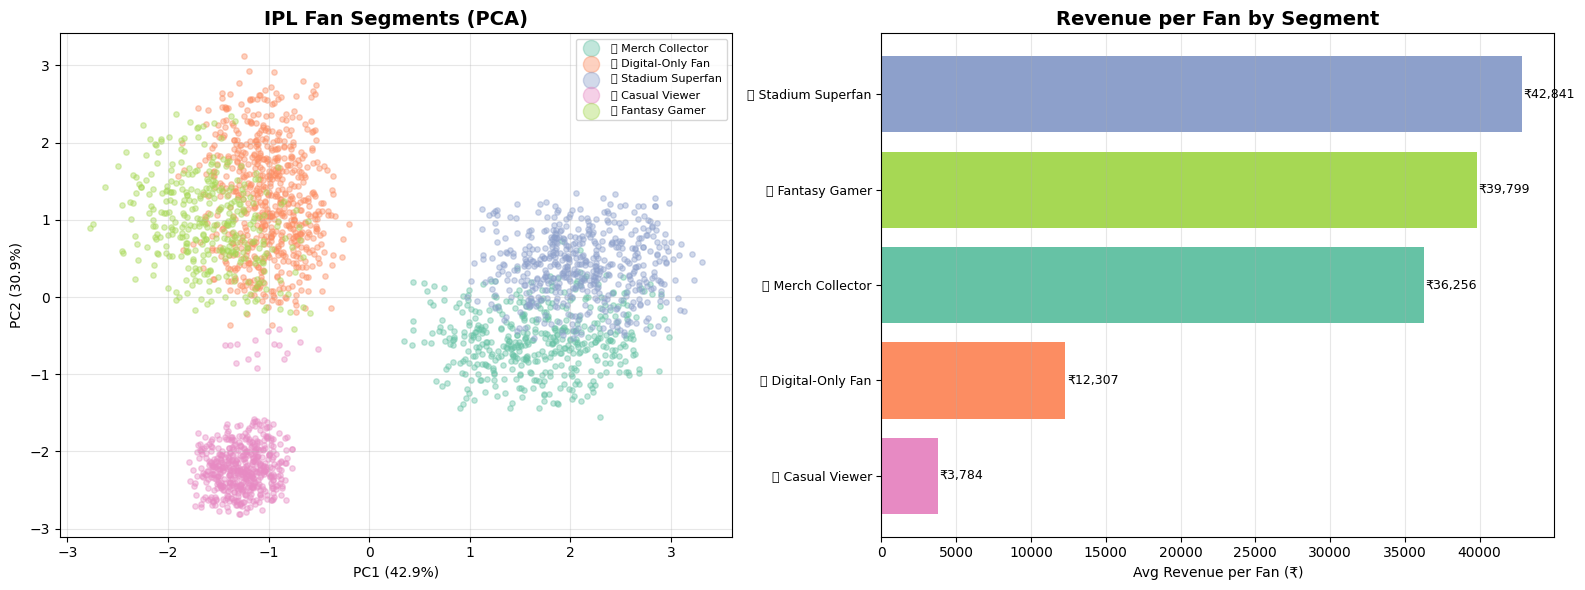

In [4]:
# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
colors = plt.cm.Set2.colors
for c in range(K):
    mask = df['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[c]],
                    label=profile.loc[c, 'persona'], alpha=0.4, s=15)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('IPL Fan Segments (PCA)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=8, markerscale=3)
axes[0].grid(True, alpha=0.3)

# Revenue by segment bar chart
seg_revenue = df.groupby('cluster')['est_revenue'].mean().sort_values(ascending=True)
bar_colors = [colors[i] for i in seg_revenue.index]
bar_labels = [profile.loc[i, 'persona'] for i in seg_revenue.index]
axes[1].barh(range(K), seg_revenue.values, color=bar_colors)
axes[1].set_yticks(range(K))
axes[1].set_yticklabels(bar_labels, fontsize=9)
axes[1].set_xlabel('Avg Revenue per Fan (₹)')
axes[1].set_title('Revenue per Fan by Segment', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(seg_revenue.values):
    axes[1].text(v + 100, i, f'₹{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 5: Campaign ROI & Revenue Strategy Analysis

In [5]:
# === Campaign ROI Analysis ===

print("=" * 70)
print("CAMPAIGN ROI ANALYSIS: Converting Digital Fans to Stadium Visitors")
print("=" * 70)

# Find digital-only segment
digital_idx = profile[profile['persona'].str.contains('Digital')].index
if len(digital_idx) == 0:
    digital_idx = profile['streaming_hours'].idxmax()
    digital_label = profile.loc[digital_idx, 'persona']
else:
    digital_idx = digital_idx[0]
    digital_label = profile.loc[digital_idx, 'persona']

digital_fans = df[df['cluster'] == digital_idx]

print(f"\n📱 TARGET SEGMENT: {digital_label}")
print(f"   Size: {len(digital_fans):,} fans")
print(f"   Current match attendance: {digital_fans['match_attendance'].mean():.1f}")
print(f"   Streaming hours: {digital_fans['streaming_hours'].mean():.1f}")
print(f"   Current avg revenue: ₹{digital_fans['est_revenue'].mean():,.0f}")

# Scenario: 5% conversion to attend 2 games
conversion_rate = 0.05
games_attended = 2
converted_fans = len(digital_fans) * conversion_rate
ticket_revenue = converted_fans * games_attended * avg_ticket_price
fb_revenue = converted_fans * games_attended * 800  # ₹800 F&B per visit
merch_uplift = converted_fans * 1500  # ₹1500 impulse merchandise

total_incremental = ticket_revenue + fb_revenue + merch_uplift
campaign_cost = len(digital_fans) * 50  # ₹50 per fan marketing cost

print(f"\n📊 CONVERSION SCENARIO (5% attend 2 games):")
print(f"   Fans converted: {converted_fans:.0f}")
print(f"   Ticket revenue: ₹{ticket_revenue:,.0f}")
print(f"   F&B revenue: ₹{fb_revenue:,.0f}")
print(f"   Merch uplift: ₹{merch_uplift:,.0f}")
print(f"   Total incremental: ₹{total_incremental:,.0f}")
print(f"   Campaign cost: ₹{campaign_cost:,.0f}")
print(f"   ROI: {(total_incremental / campaign_cost - 1) * 100:.0f}%")

print(f"\n🎯 SEGMENTED vs MASS MARKETING:")
mass_cost = len(df) * 50
mass_revenue = total_incremental * 0.3  # mass marketing 70% less effective
print(f"   Mass marketing: Cost ₹{mass_cost:,.0f} | Revenue ₹{mass_revenue:,.0f} | ROI: {(mass_revenue/mass_cost-1)*100:.0f}%")
print(f"   Targeted:       Cost ₹{campaign_cost:,.0f} | Revenue ₹{total_incremental:,.0f} | ROI: {(total_incremental/campaign_cost-1)*100:.0f}%")
print(f"   → Segmented approach is {total_incremental/campaign_cost / (mass_revenue/mass_cost):.1f}x more efficient")

CAMPAIGN ROI ANALYSIS: Converting Digital Fans to Stadium Visitors

📱 TARGET SEGMENT: 📱 Digital-Only Fan
   Size: 654 fans
   Current match attendance: 0.7
   Streaming hours: 75.7
   Current avg revenue: ₹12,307

📊 CONVERSION SCENARIO (5% attend 2 games):
   Fans converted: 33
   Ticket revenue: ₹163,500
   F&B revenue: ₹52,320
   Merch uplift: ₹49,050
   Total incremental: ₹264,870
   Campaign cost: ₹32,700
   ROI: 710%

🎯 SEGMENTED vs MASS MARKETING:
   Mass marketing: Cost ₹125,000 | Revenue ₹79,461 | ROI: -36%
   Targeted:       Cost ₹32,700 | Revenue ₹264,870 | ROI: 710%
   → Segmented approach is 12.7x more efficient
